<a href="https://colab.research.google.com/github/koniitinomiya-prog/crack-detection/blob/main/Crack_detection_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crack Detection CNN

コンクリートのひび割れ検出を行うCNNモデルです。

授業のFashion MNISTと同じ流れで実装します：
1. Data Prep
2. Define Model
3. Set Optimization Parameters
4. Train Model
5. Evaluate Model

**データセット**: SDNET2018
- 56,000枚以上のコンクリート画像（ひびあり／なし）
- Bridge decks (D), Walls (W), Pavements (P)
- 各画像は256×256px

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ★ここをあなたのDrive上のパスに合わせる
ROOT = "/content/drive/MyDrive/SDNET2018"

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os, glob, random
from pathlib import Path
import re
from collections import defaultdict

# 再現性のためにシードを固定（授業と同じ）
keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: True


## 1. Data Prep

SDNET2018はGoogle Driveに保存されているため、自分でファイルを読み込む必要があります。

In [ ]:
# ファイルパスとラベル（0=ひびなし, 1=ひびあり）を収集
def collect_paths(root):
    items = []
    for surface in ["D"]:          # Bridge, Pavement, Wall["D", "P", "W"]
        for cls_folder, label in [("CD", 1),  # Cracked    → 1
                                   ("UD", 0)]: # Uncracked  → 0
            pattern = os.path.join(root, surface, cls_folder, "*.jpg")
            for p in glob.glob(pattern):
                items.append((p, label))
    return items

items = collect_paths(ROOT)
print("Total images:", len(items))
print("Example:", items[0] if items else None)

Total images: 13620
Example: ('/content/drive/MyDrive/SDNET2018/D/CD/7020-152.jpg', 1)


In [ ]:
# ★グループ単位でTrain/Val/Testに分割（データリーク防止）
# 同じ元画像から切り出したタイルは必ず同じsplitに入れる
def group_key(path):
    name = Path(path).stem   # 例: "7001-56" → "7001"
    m = re.match(r"^(\d+)-", name)
    return m.group(1) if m else name

group_to_indices = defaultdict(list)
for i, (p, y) in enumerate(items):
    group_to_indices[group_key(p)].append(i)

groups = list(group_to_indices.keys())
random.seed(42)
random.shuffle(groups)

n = len(groups)
train_g = set(groups[:int(0.8*n)])
val_g   = set(groups[int(0.8*n):int(0.9*n)])
test_g  = set(groups[int(0.9*n):])

train_idx, val_idx, test_idx = [], [], []
for g, idxs in group_to_indices.items():
    if   g in train_g: train_idx += idxs
    elif g in val_g:   val_idx   += idxs
    else:              test_idx  += idxs

print(f"Train: {len(train_idx)} images")
print(f"Val:   {len(val_idx)} images")
print(f"Test:  {len(test_idx)} images")

Train: 10844 images
Val:   1260 images
Test:  1516 images


In [ ]:
# ★画像数を絞る（速度改善）
# クラスごとに最大2000枚に制限（ひびあり2000 + ひびなし2000 = 4000枚/split）
MAX_PER_CLASS = 2000

def subsample(indices, items, max_per_class):
    class0 = [i for i in indices if items[i][1] == 0]
    class1 = [i for i in indices if items[i][1] == 1]
    random.seed(42)
    # ★両クラスをmin枚数に揃える（Undersampling）
    n = min(max_per_class, len(class0), len(class1))
    class0 = random.sample(class0, n)
    class1 = random.sample(class1, n)
    return class0 + class1

train_idx = subsample(train_idx, items, MAX_PER_CLASS)
val_idx   = subsample(val_idx,   items, MAX_PER_CLASS // 4)
test_idx  = subsample(test_idx,  items, MAX_PER_CLASS // 4)

print(f"Train: {len(train_idx)} / Val: {len(val_idx)} / Test: {len(test_idx)}")

Train: 3176 / Val: 408 / Test: 466


In [ ]:
# 画像を読み込んでnumpy配列に変換
# 授業と同様に 0-1 に正規化（÷255）
from tqdm.auto import tqdm

IMG_SIZE = 64

def load_images(indices, items, desc="Loading"):
    X, y = [], []
    for i in tqdm(indices, desc=desc):  # ★進捗バーを追加
        path, label = items[i]
        img = keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
        arr = keras.utils.img_to_array(img) / 255.0
        X.append(arr)
        y.append(label)
    return np.array(X), np.array(y)

print("Loading train images...")
x_train, y_train = load_images(train_idx, items, desc="Train")
print("Loading val images...")
x_val, y_val = load_images(val_idx, items, desc="Val")
print("Loading test images...")
x_test, y_test = load_images(test_idx, items, desc="Test")

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

Loading train images...


Train:   0%|          | 0/3176 [00:00<?, ?it/s]

Loading val images...


Val:   0%|          | 0/408 [00:00<?, ?it/s]

Loading test images...


Test:   0%|          | 0/466 [00:00<?, ?it/s]

x_train shape: (3176, 64, 64, 3)
y_train shape: (3176,)


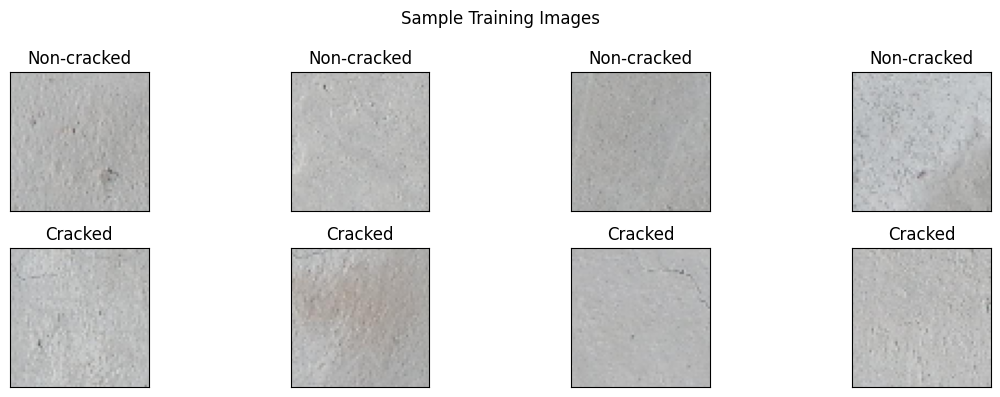

In [ ]:
# ひびあり・なしを4枚ずつ表示
labels = ["Non-cracked", "Cracked"]

cracked_idx    = np.where(y_train == 1)[0][:4]  # Crackedを4枚
noncracked_idx = np.where(y_train == 0)[0][:4]  # Non-crackedを4枚
sample_idx = np.concatenate([noncracked_idx, cracked_idx])

figure = plt.figure(figsize=(12, 4))
for i, idx in enumerate(sample_idx):
    ax = figure.add_subplot(2, 4, i+1, xticks=[], yticks=[])
    ax.imshow(x_train[idx])
    ax.set_title(labels[int(y_train[idx])])
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

## 2. Define Model

授業のFashion MNISTとほぼ同じ構造です。

違いは：
- 入力: `(256, 256, 3)` ← カラー画像（RGBの3チャンネル）
- 出力: `Dense(1, sigmoid)` ← 2クラス分類（ひびあり／なし）

```
Fashion MNIST:  Dense(10, softmax)  ← 10クラス分類
Crack Detection: Dense(1, sigmoid)  ← 2クラス分類
```

In [ ]:
input = keras.Input(shape=x_train.shape[1:])  # (64, 64, 3)


# ==============================
# 【追加】Data Augmentation
# 訓練時だけランダムに画像を変形して水増しする
# → 同じ画像を何度も見せず過学習を防ぐ
# ※ model.predict()時は自動でOFFになる
# ==============================
x = keras.layers.RandomFlip("horizontal_and_vertical")(input) # 左右・上下反転
x = keras.layers.RandomRotation(0.15)(x)                      # ±15%回転
x = keras.layers.RandomZoom(0.1)(x)                           # ±10%拡縮



# ==============================
# 第1 Conv Block
# ==============================
# 【元と同じ】32フィルターで3×3の特徴を抽出
x = keras.layers.Conv2D(32, (3,3), padding="same")(input)

# 【追加】BatchNormalization
# Conv2Dの出力値を「平均0・分散1」に正規化する
# → 学習初期の不安定さ（Epoch1〜16がランダムだった問題）を解消
# ※ Conv2D の中に activation="relu" を書くとBNを挟めないので
#   activation は外に出してBNの後に書く
x = keras.layers.BatchNormalization()(x)

# 【元と同じ・書き方だけ変更】ReLUで負の値を0にする
# 元: Conv2D(..., activation="relu") と一緒に書いていた
# 新: BNを挟むために Activation を別レイヤーとして分離
x = keras.layers.Activation("relu")(x)

# 【元と同じ】64×64 → 32×32 に縮小（計算量削減）
x = keras.layers.MaxPool2D()(x)

# ==============================
# 第2 Conv Block
# ==============================
# 【元と同じ】64フィルターでより複雑な特徴を抽出
x = keras.layers.Conv2D(64, (3,3), padding="same")(x)

# 【追加】BatchNormalization（第1 Blockと同じ理由）
x = keras.layers.BatchNormalization()(x)

# 【元と同じ・書き方だけ変更】
x = keras.layers.Activation("relu")(x)

# 【元と同じ】32×32 → 16×16 に縮小
x = keras.layers.MaxPool2D()(x)

# ==============================
# 全結合層（元と完全に同じ）
# ==============================
# 2D特徴マップ(16×16×64)を1次元ベクトルに変換
x = keras.layers.Flatten()(x)

# 256ニューロンで高レベルな特徴を学習
x = keras.layers.Dense(256, activation="relu")(x)

# 50%のニューロンをランダムに無効化して過学習を防ぐ
x = keras.layers.Dropout(0.5)(x)

# ==============================
# 出力層（元と完全に同じ）
# ==============================
# sigmoid: 0〜1の確率を出力（0.5以上→ひびあり）
output = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(input, output)





model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,593 (16.08 MB)

 Trainable params: 4,214,401 (16.08 MB)

 Non-trainable params: 192 (768.00 B)

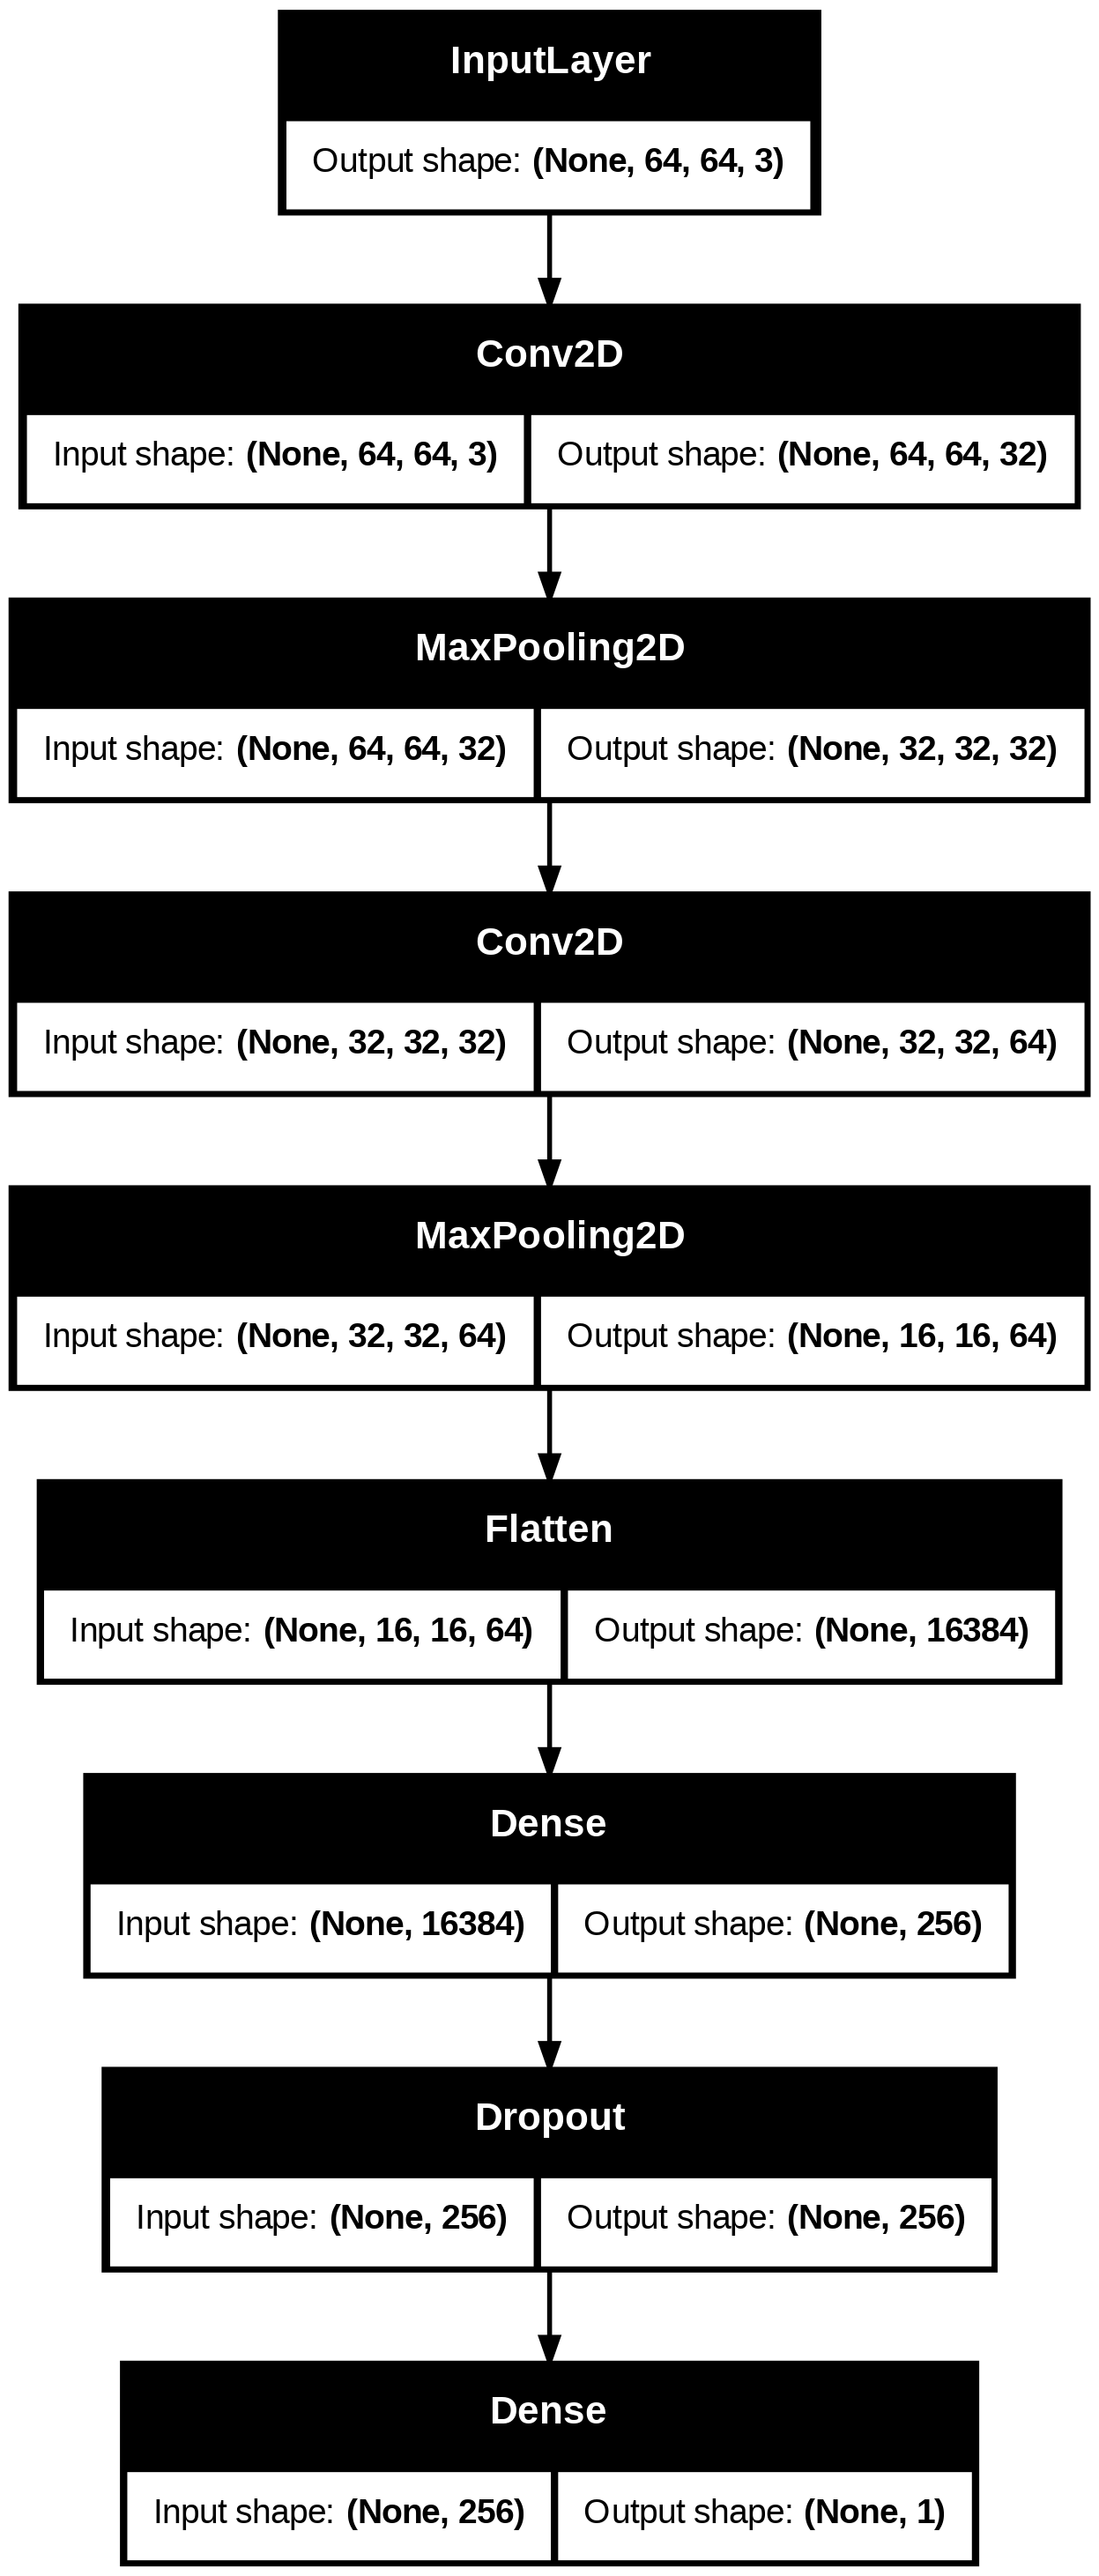

In [ ]:
# モデル構造を図で確認（授業と同じ）
keras.utils.plot_model(model, show_shapes=True)

## 3. Set Optimization Parameters

授業との違い：
- 損失関数: `binary_crossentropy`（2クラスなのでbinary）
  - 授業: `sparse_categorical_crossentropy`（10クラス）
- メトリクス: `accuracy` に加えて `Recall` も監視

In [ ]:
model.compile(
    loss='binary_crossentropy',   # ★2クラス分類用（授業は sparse_categorical）
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),             # ★授業と同じ
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),       # ひび割れの見逃し率監視
        keras.metrics.Precision(name='precision')  # 誤検出率監視
    ]
)

## 4. Train the Model

In [ ]:
# 授業と同じplot関数（loss と accuracy）
def plot_loss_curves(history):
    plt.clf()
    plt.plot(history.history["loss"],     "bo", label="Training loss")
    plt.plot(history.history["val_loss"], "b",  label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_acc_curves(history):
    plt.clf()
    plt.plot(history.history["accuracy"],     "bo", label="Training acc")
    plt.plot(history.history["val_accuracy"], "b",  label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def plot_recall_curves(history):
    plt.clf()
    plt.plot(history.history["recall"],     "ro", label="Training recall")
    plt.plot(history.history["val_recall"], "r",  label="Validation recall")
    plt.axhline(y=0.95, color='gray', linestyle='--', label="Target (0.95)")
    plt.title("Training and validation recall")
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()
    plt.show()

In [ ]:
# クラスの重みを計算
total = len(y_train)
n0 = np.sum(y_train == 0)  # Non-cracked
n1 = np.sum(y_train == 1)  # Cracked

# class_weightを手動で設定
class_weight = {0: 1.0, 1: 1}  # Crackedの罰則を2倍
print("class_weight:", class_weight)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(x_val, y_val),
    class_weight=class_weight,
    callbacks=[early_stop]  # ← 追加
)

class_weight: {0: 1.0, 1: 1}
Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.5676 - loss: 1.0355 - precision: 0.5711 - recall: 0.5793 - val_accuracy: 0.5025 - val_loss: 0.6937 - val_precision: 1.0000 - val_recall: 0.0049
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5936 - loss: 0.6700 - precision: 0.6125 - recall: 0.5501 - val_accuracy: 0.5000 - val_loss: 0.6996 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6058 - loss: 0.6609 - precision: 0.6267 - recall: 0.5705 - val_accuracy: 0.5025 - val_loss: 0.7030 - val_precision: 1.0000 - val_recall: 0.0049
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6189 - loss: 0.6525 - precision: 0.6624 - recall: 0.5419 - val_accuracy: 0.5270 - val_loss: 0.6862 - val_precision: 0.9231 - val_recall: 0.0588
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6283 - loss: 0.6401 - precision: 0.6735 - recall: 0.5313

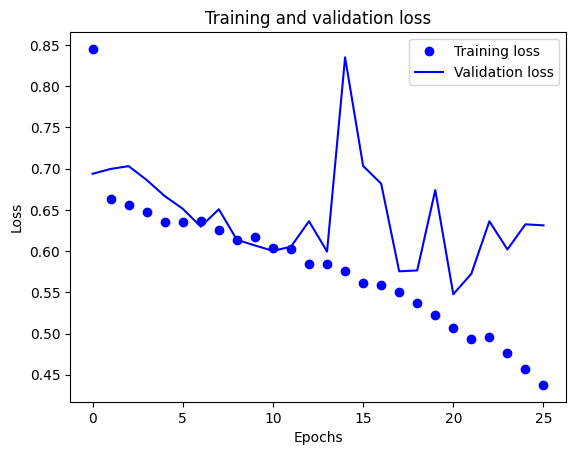

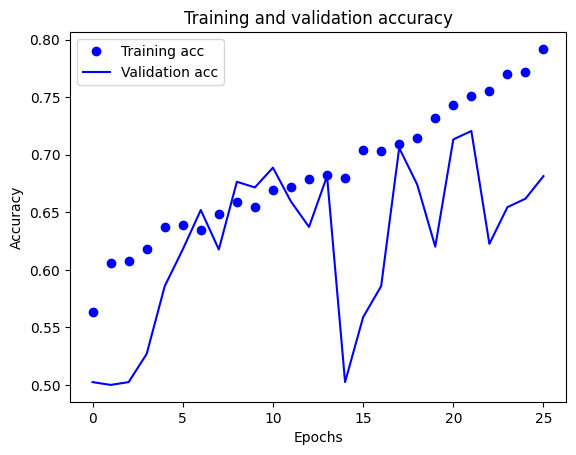

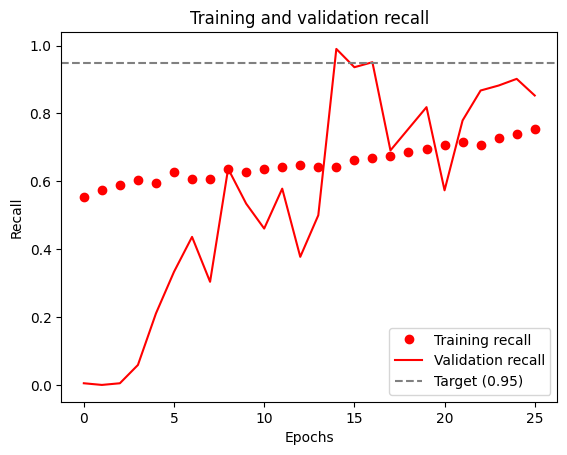

In [ ]:
# 授業と同じ：lossとaccuracyのグラフ
plot_loss_curves(history)
plot_acc_curves(history)

# ひび割れ検出特有：Recallのグラフ
plot_recall_curves(history)

## 5. Evaluate the Model

In [ ]:
# 授業と同じ：model.evaluate()
score = model.evaluate(x_test, y_test)
print("Test loss:     ", score[0])
print("Test accuracy: ", score[1])
print("Test recall:   ", score[2])
print("Test precision:", score[3])

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7478 - loss: 0.5679 - precision: 0.2999 - recall: 0.2090
Test loss:      0.6826843023300171
Test accuracy:  0.6158798336982727
Test recall:    0.3991416394710541
Test precision: 0.7045454382896423


In [ ]:
# 予測（授業と同じ：model.predict()）
y_prob = model.predict(x_test).flatten()  # 各画像のひびあり確率
y_pred = (y_prob >= 0.5).astype(int)      # 0.5を閾値に0/1に変換

# 間違えた画像を表示（授業と同じスタイル）
misses = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(misses)} / {len(y_test)} images")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Misclassified: 179 / 466 images


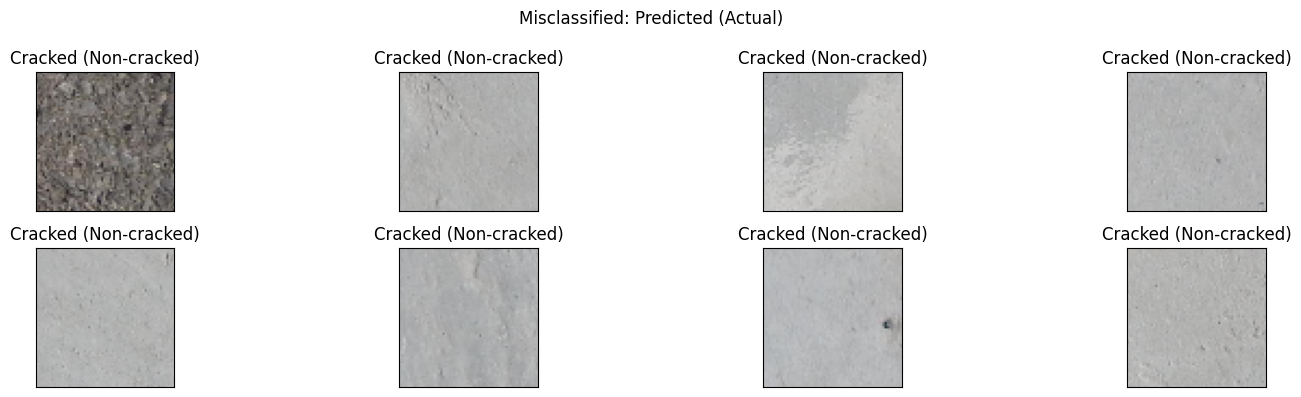

In [ ]:
# 間違えた画像を表示（授業と同じスタイル）
sample = np.random.choice(misses, size=min(8, len(misses)), replace=False)
figure = plt.figure(figsize=(16, 4))
for i, idx in enumerate(sample):
    ax = figure.add_subplot(2, 4, i+1, xticks=[], yticks=[])
    ax.imshow(x_test[idx])
    ax.set_title("{} ({})".format(
        labels[y_pred[idx]],
        labels[y_test[idx]]
    ))
plt.suptitle("Misclassified: Predicted (Actual)")
plt.tight_layout()
plt.show()

## 6. Bonus: ヒートマップで「どこにひびがあるか」を可視化

大きな壁の写真を256×256に切り分けて、ひびがある場所をヒートマップで表示します。

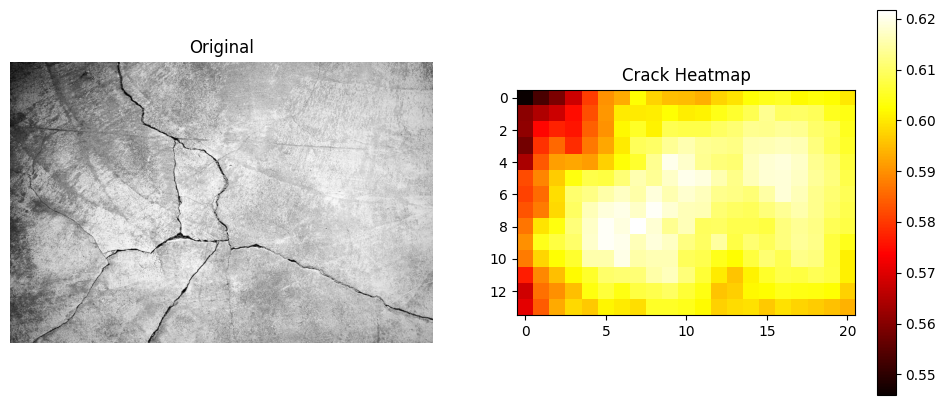

In [ ]:
import math
from PIL import Image

def crack_heatmap(image_path, model, tile=64, stride=16):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    nx = math.floor((W - tile) / stride) + 1
    ny = math.floor((H - tile) / stride) + 1
    heat = np.zeros((ny, nx), dtype=np.float32)

    for iy in range(ny):
        for ix in range(nx):
            x0, y0 = ix * stride, iy * stride
            crop = img.crop((x0, y0, x0 + tile, y0 + tile))
            arr = np.array(crop) / 255.0
            arr = np.expand_dims(arr, 0)  # (1, 256, 256, 3)
            prob = model.predict(arr, verbose=0)[0][0]
            heat[iy, ix] = prob

    return img, heat

# 使い方

large_img_path = "/content/drive/MyDrive/your_wall_photo.jpg"  # ★実際のファイル名に変える
img, heat = crack_heatmap(large_img_path, model, tile=64, stride=32)  # ★tile=64に変更

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1); plt.imshow(img); plt.axis("off"); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(heat, cmap="hot"); plt.colorbar(); plt.title("Crack Heatmap")
plt.show()